# Buscar imágenes en Wikimedia Commons

Notebook interactivo para buscar, evaluar visualmente y descargar imágenes de retratos desde Wikimedia Commons, siguiendo el procedimiento de `docs/obtener-imagenes-wikimedia.md`.

**Flujo:**
1. Buscar candidatos por nombre
2. Inspeccionar tabla de calidad + thumbnails
3. Elegir un índice y descargar
4. Copiar el caption generado para el `aside`

## Configuración

In [8]:
import urllib.request, urllib.parse, json, io, re, os
from IPython.display import display, Image as IPImage, Markdown
from PIL import Image as PILImage

RAIZ = os.path.abspath(os.path.join(os.getcwd(), '..'))

def limpiar_html(texto):
    """Quita etiquetas HTML y recorta texto largo."""
    return re.sub(r'<[^>]+>', '', texto or '').strip()

def buscar_imagenes(termino, limite=20):
    """Busca imágenes en Commons. Devuelve lista de dicts con metadatos."""
    query = urllib.parse.quote(termino)
    url = (
        f'https://commons.wikimedia.org/w/api.php?action=query'
        f'&generator=search&gsrsearch={query}&gsrnamespace=6'
        f'&gsrlimit={limite}&prop=imageinfo'
        f'&iiprop=url|extmetadata|size|thumburl&iiurlwidth=300&format=json'
    )
    req = urllib.request.Request(url, headers={'User-Agent': 'MMFI1-docs/1.0'})
    with urllib.request.urlopen(req) as resp:
        data = json.loads(resp.read())
    candidatos = []
    if 'query' in data:
        for page in data['query']['pages'].values():
            ii = page.get('imageinfo', [{}])[0]
            meta = ii.get('extmetadata', {})
            w, h = ii.get('width', 0), ii.get('height', 0)
            ok = w >= 400 and h >= 500
            candidatos.append({
                'titulo': page['title'],
                'ancho': w,
                'alto': h,
                'calidad': 'ok' if ok else 'baja',
                'artista': limpiar_html(meta.get('Artist', {}).get('value', '?'))[:70],
                'licencia': meta.get('LicenseShortName', {}).get('value', '?'),
                'url': ii.get('url', ''),
                'thumburl': ii.get('thumburl', ''),
            })
    return sorted(candidatos, key=lambda c: (c['calidad'] != 'ok', -(c['ancho'] * c['alto'])))

def mostrar_tabla(candidatos):
    """Muestra tabla Markdown con calidad y dimensiones."""
    filas = [
        f'| {i} | {c["calidad"]} | {c["ancho"]}\u00d7{c["alto"]} | {c["licencia"]} | {c["artista"]} |'
        for i, c in enumerate(candidatos)
    ]
    header = '| # | Calidad | Dimensiones | Licencia | Autor |\n|---|---------|-------------|----------|-------|\n'
    display(Markdown(header + '\n'.join(filas)))

def mostrar_thumbnails(candidatos, solo_ok=False):
    """Muestra thumbnails inline con su \u00edndice."""
    for i, c in enumerate(candidatos):
        if solo_ok and c['calidad'] != 'ok':
            continue
        if not c['thumburl']:
            continue
        display(Markdown(f'**[{i}]** {c["titulo"]} \u2014 {c["ancho"]}\u00d7{c["alto"]} \u2014 {c["licencia"]}'))
        display(IPImage(url=c['thumburl'], width=250))

def descargar(candidatos, indice, destino, max_ancho=800):
    """Descarga, redimensiona y guarda la imagen. Devuelve info para el caption."""
    c = candidatos[indice]
    req = urllib.request.Request(c['url'], headers={'User-Agent': 'MMFI1-docs/1.0'})
    with urllib.request.urlopen(req) as resp:
        raw = resp.read()
    img = PILImage.open(io.BytesIO(raw))
    original = img.size
    if img.size[0] > max_ancho:
        ratio = max_ancho / img.size[0]
        img = img.resize((max_ancho, int(img.size[1] * ratio)), PILImage.LANCZOS)
    os.makedirs(os.path.dirname(destino), exist_ok=True)
    if img.mode == 'RGBA' or img.mode == 'P':
        img = img.convert('RGB')
    img.save(destino, 'JPEG', quality=90, optimize=True)
    tamano_kb = os.path.getsize(destino) // 1024
    print(f'Descargado: {original[0]}\u00d7{original[1]} \u2192 {img.size[0]}\u00d7{img.size[1]} ({tamano_kb} KB)')
    print(f'Guardado en: {destino}')
    display(IPImage(filename=destino, width=300))
    return c

def generar_caption(c, nombre, fechas):
    """Genera el texto del caption para el aside de MyST."""
    commons = f'https://commons.wikimedia.org/wiki/{urllib.parse.quote(c["titulo"].replace(" ", "_"))}'
    return f'{nombre} ({fechas}). Foto: {c["artista"]} ([Wikimedia Commons]({commons}), {c["licencia"]}).'

print('Listo.')

Listo.


---
## Paso 1: Buscar

Editar `BUSQUEDA` con el nombre de la persona y ejecutar.

In [10]:
BUSQUEDA = 'Ana María Cetto '

candidatos = buscar_imagenes(BUSQUEDA)
print(f'{len(candidatos)} resultados para "{BUSQUEDA}"\n')
mostrar_tabla(candidatos)

20 resultados para "Ana María Cetto "



| # | Calidad | Dimensiones | Licencia | Autor |
|---|---------|-------------|----------|-------|
| 0 | ok | 4592×3064 | CC BY-SA 4.0 | Luis Alvaz |
| 1 | ok | 4592×3064 | CC BY-SA 4.0 | Luis Alvaz |
| 2 | ok | 4592×3064 | CC BY-SA 4.0 | Luis Alvaz |
| 3 | ok | 3064×4592 | CC BY-SA 4.0 | Luis Alvaz |
| 4 | ok | 4592×3064 | CC BY-SA 4.0 | Luis Alvaz |
| 5 | ok | 4592×3064 | CC BY-SA 4.0 | Luis Alvaz |
| 6 | ok | 4592×3064 | CC BY-SA 4.0 | Luis Alvaz |
| 7 | ok | 4592×3064 | CC BY-SA 4.0 | Luis Alvaz |
| 8 | ok | 4592×3064 | CC BY-SA 4.0 | Luis Alvaz |
| 9 | ok | 4592×3064 | CC BY-SA 4.0 | Luis Alvaz |
| 10 | ok | 4592×3064 | CC BY-SA 4.0 | Luis Alvaz |
| 11 | ok | 4592×3064 | CC BY-SA 4.0 | Luis Alvaz |
| 12 | ok | 3456×2304 | CC BY 2.0 | The Official CTBTO Photostream |
| 13 | ok | 3008×2000 | CC BY 2.0 | IAEA Imagebank |
| 14 | ok | 2889×1921 | CC BY 2.0 | IAEA Imagebank |
| 15 | ok | 2885×1918 | CC BY 2.0 | IAEA Imagebank |
| 16 | ok | 2865×1906 | CC BY 2.0 | IAEA Imagebank |
| 17 | ok | 2835×1884 | CC BY 2.0 | IAEA Imagebank |
| 18 | ok | 2780×1848 | CC BY-SA 2.0 | IAEA Imagebank |
| 19 | ok | 1389×1839 | CC BY-SA 2.0 | IAEA Imagebank |

## Paso 2: Inspeccionar thumbnails

Revisar visualmente calidad y orientaci\u00f3n antes de elegir.

In [11]:
mostrar_thumbnails(candidatos, solo_ok=False)

**[0]** File:Conferencia de Ana María Cetto por el 50 aniversario de la UAA 15.jpg — 4592×3064 — CC BY-SA 4.0

**[1]** File:Conferencia de Ana María Cetto por el 50 aniversario de la UAA 21.jpg — 4592×3064 — CC BY-SA 4.0

**[2]** File:Conferencia de Ana María Cetto por el 50 aniversario de la UAA 30.jpg — 4592×3064 — CC BY-SA 4.0

**[3]** File:Conferencia de Ana María Cetto por el 50 aniversario de la UAA 35.jpg — 3064×4592 — CC BY-SA 4.0

**[4]** File:Conferencia de Ana María Cetto por el 50 aniversario de la UAA 36.jpg — 4592×3064 — CC BY-SA 4.0

...

**[15]** File:Ana Maria Cetto (01210615).jpg — 2885×1918 — CC BY 2.0

**[16]** File:Ana Maria Cetto (01210614).jpg — 2865×1906 — CC BY 2.0

**[17]** File:Ana Maria Cetto (01210611).jpg — 2835×1884 — CC BY 2.0

**[18]** File:Ana Maria Cetto (01310701) (4874995165).jpg — 2780×1848 — CC BY-SA 2.0

**[19]** File:Ana María Cetto.jpg — 1389×1839 — CC BY-SA 2.0

---
## Paso 3: Descargar

Elegir el \u00edndice de la imagen deseada (columna `#` de la tabla) y definir el `DESTINO`.
La convenci\u00f3n del proyecto es `Nombre_Apellido.jpg`.

Descargado: 3456×2304 → 800×533 (67 KB)
Guardado en: /home/glacy/mmfi1/02_numeros_complejos/images/Ana_Maria_Cetto.png


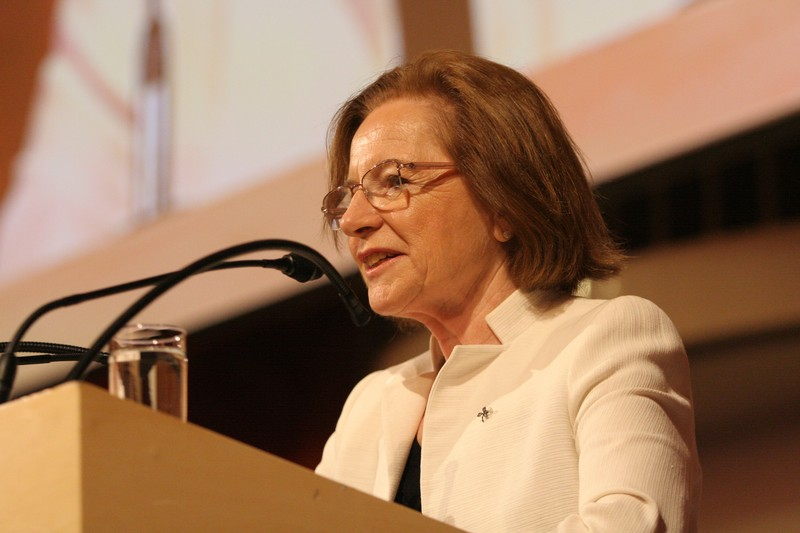

In [13]:
INDICE  = 12  # cambiar seg\u00fan la tabla/thumbnails
DESTINO = os.path.join(RAIZ, '02_numeros_complejos/images/Ana_Maria_Cetto.png')

info = descargar(candidatos, INDICE, DESTINO, max_ancho=800)

## Paso 4: Caption para el aside

Editar `NOMBRE` y `FECHAS`, luego copiar el texto generado al `{figure}` del aside.

In [14]:
NOMBRE  = 'Ana María Cetto'
FECHAS  = '1946 - '

caption = generar_caption(info, NOMBRE, FECHAS)
print(caption)

Ana María Cetto (1946 - ). Foto: The Official CTBTO Photostream ([Wikimedia Commons](https://commons.wikimedia.org/wiki/File%3AAna_Maria_Cetto.jpg), CC BY 2.0).
